# Предсказания отклика клиента на маркетинговую кампанию

Сегодня мы попытаем решить задачу предсказания отклика клиента на маркетинговую кампанию на открытом датасете.

Набор данных:  
https://www.kaggle.com/datasets/jackdaoud/marketing-data/data

## Импорт библиотек, загрузка данных

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('https://github.com/evgpat/datasets/raw/main/ifood_df_raw.csv')

## Exploratory Data Analysis (EDA)

При решении любой аналитической / ML задачи важно предварительно хорошо понять наши данные.
Поэтому начнем мы с проведения исследовательского анализа данных (EDA).
Это поможет нам:
* Понять структуру и содержание наших данных
* Выявить возможные проблемы с данными (пропущенные значения, дубликаты, выбросы)
* Определить основные характеристики переменных, распределение)
* Определить взаимосвязи между переменными

Посмотрим на наши данные.

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


AcceptedCmp1 — клиент принял оффер 1-ой кампании (1 - да, 0 - нет)  
AcceptedCmp2 — клиент принял оффер 2-ой кампании (1 - да, 0 - нет)  
AcceptedCmp3 — клиент принял оффер 3-ой кампании (1 - да, 0 - нет)  
AcceptedCmp4 — клиент принял оффер 4-ой кампании (1 - да, 0 - нет)  
AcceptedCmp5 — клиент принял оффер 5-ой кампании (1 - да, 0 - нет)    
Dt_Customer — дата
Complain — жаловался ли клиент в последние два года  
Income — доход   
Kidhome — количество маленьких детей  
Teenhome — количество детей-подростков  
Year_Birth — дата рождения  
Income — доход домохозяйства  
Траты на конкретные продукты:      
* MntFishProducts
* MntFruits
* MntGoldProds
* MntMeatProducts
* MntSweetProducts
* MntWines

NumCatalogPurchases — количество покупок из каталога  
NumDealsPurchases — количество покупок со скидкой  
NumStorePurchases — количество покупок в физических магазинах  
NumWebPurchases — количество покупок через Интернет  
NumWebVisitsMonth — количество визитов на сайт  

Recency — количество дней с последней покупки   

Education — уровень образования:
Marital_Status — семейное положение

**Response** — отклик на последнюю кампанию (будущая целевая переменная)

Начнем с метода  `df.info()`- посмотрим на типы столбцов, пропущенные значения и т.п.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum() # проверяем пропуски

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Видим, что столбец `Income` содержит пропуски

In [ ]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,2013-11-23,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,...,6,0,0,0,0,0,0,3,11,0


Вернёмся к этом проблеме позже.

Теперь используем метод `.describe()`, чтобы посчитать основные описательные статистики для числовых столбцов

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
df = df.drop(['Z_CostContact', 'Z_Revenue'], axis=1) # удаляем признаки с нулевой дисперсией

In [ ]:
df.shape

(2240, 27)

Теперь посчитаем статистики для категориальных переменных:

In [ ]:
df.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,2012-08-31
freq,1127,864,12


In [ ]:
df.select_dtypes(['int']).columns

Index(['ID', 'Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Response'],
      dtype='object')

In [ ]:
int_columns = ['Year_Birth', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

Построим распределения числовых переменных:

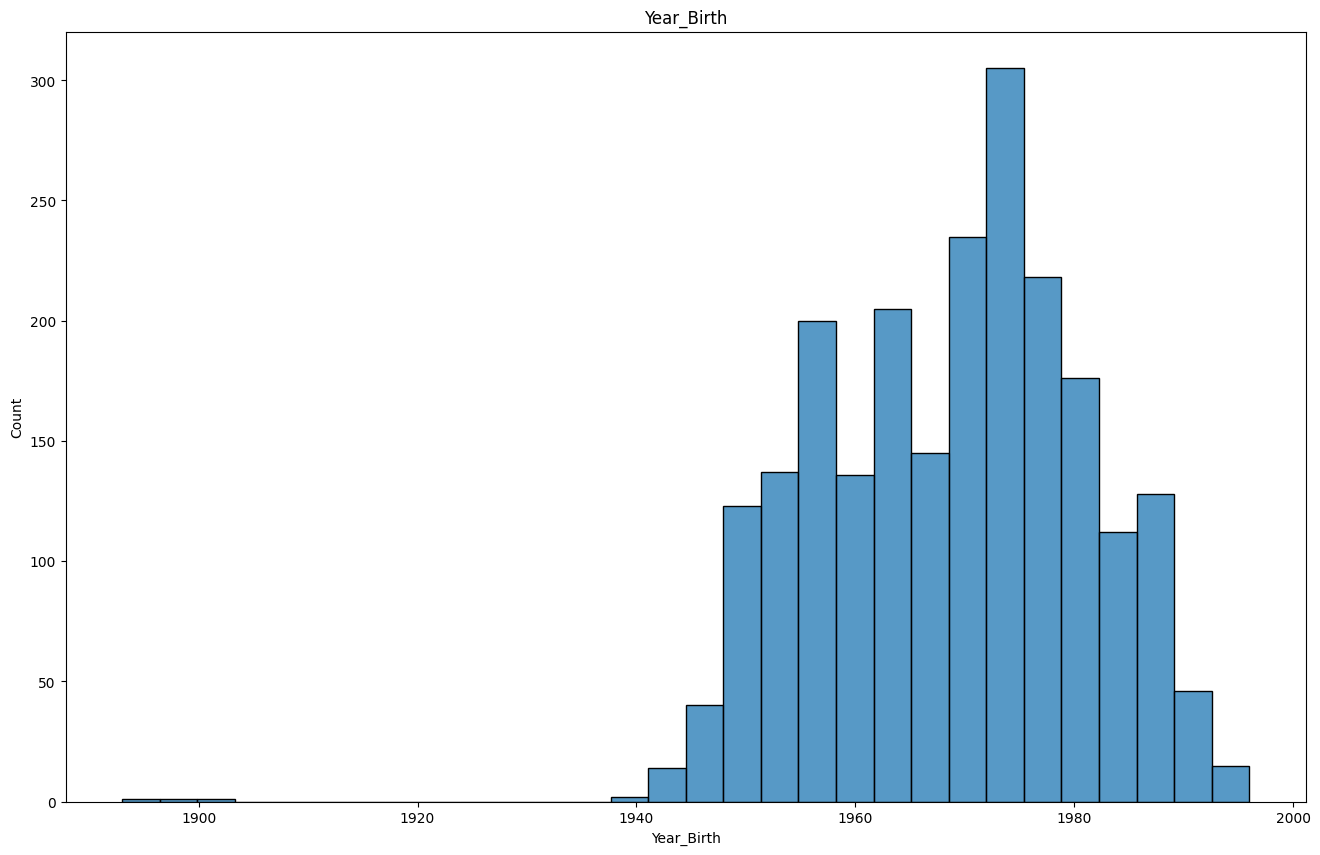

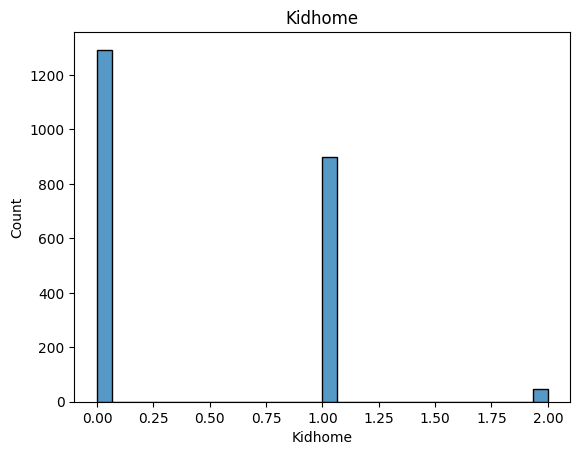

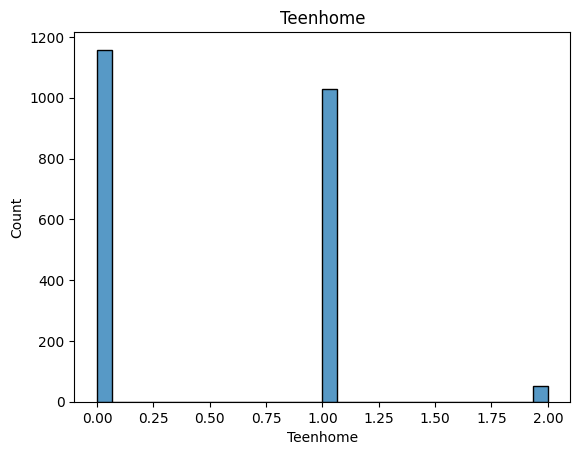

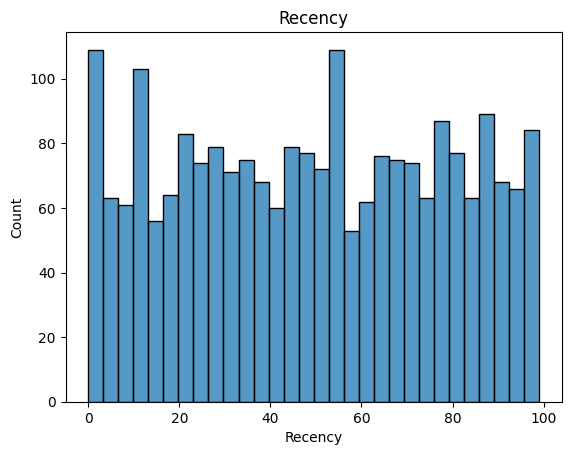

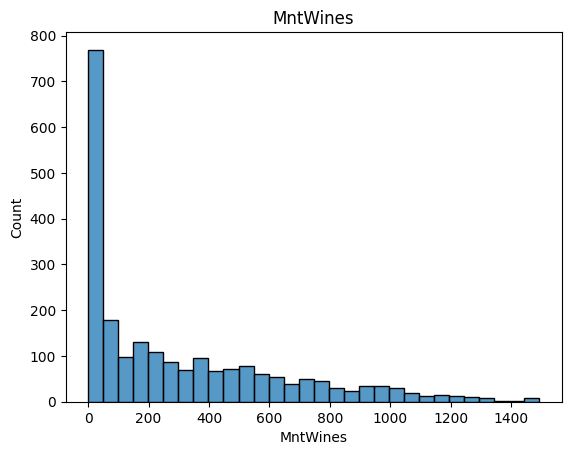

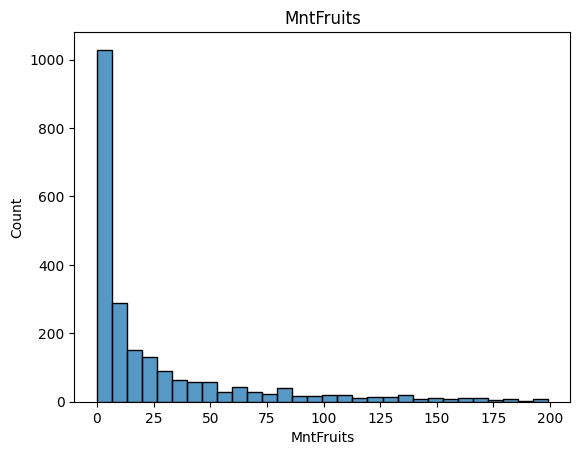

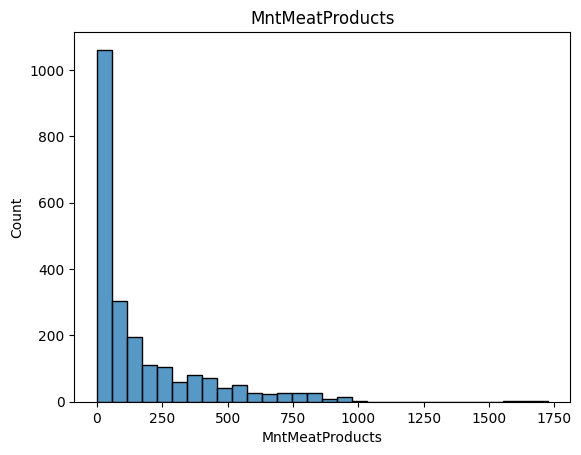

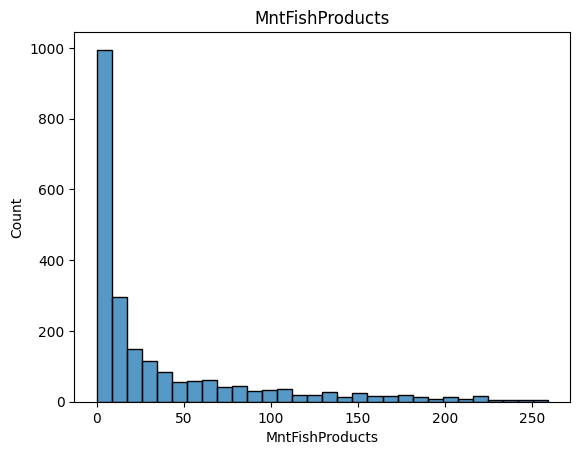

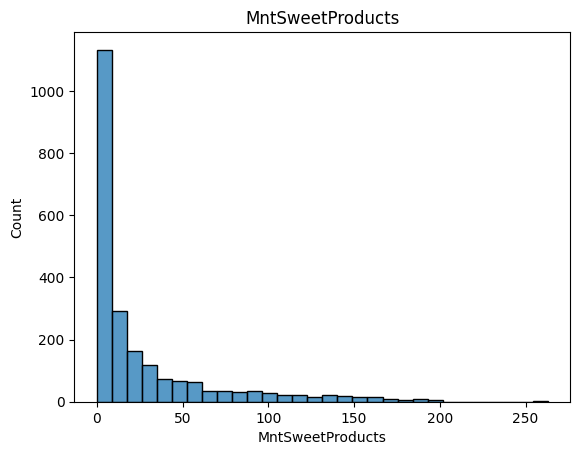

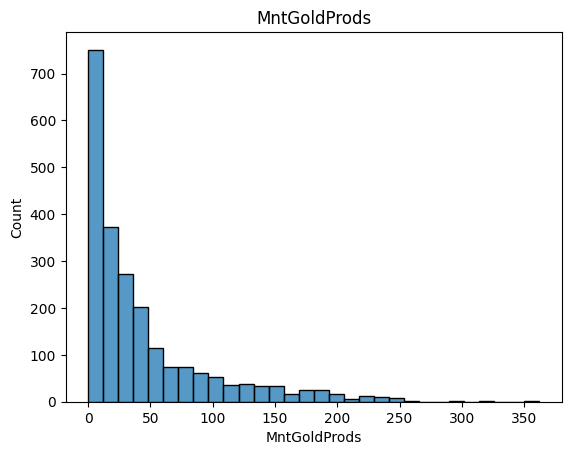

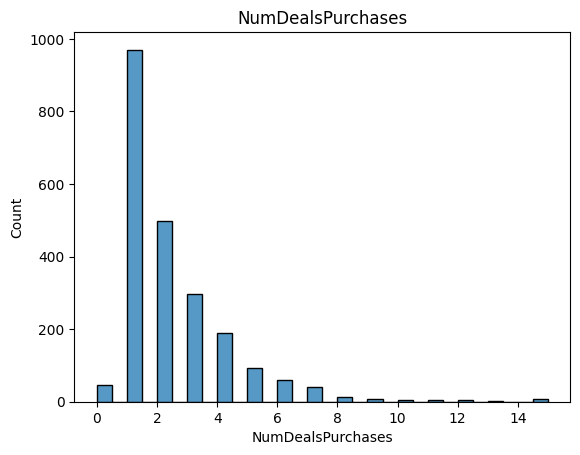

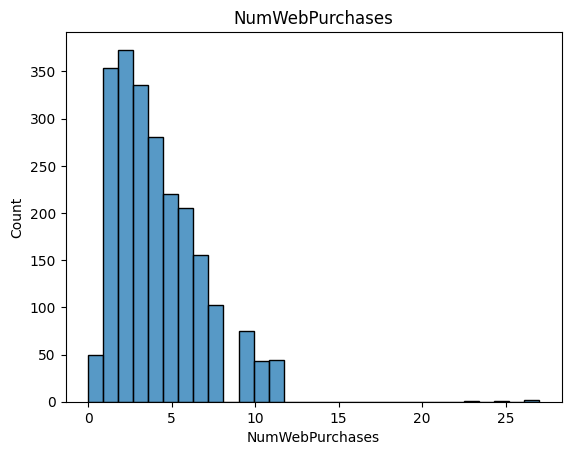

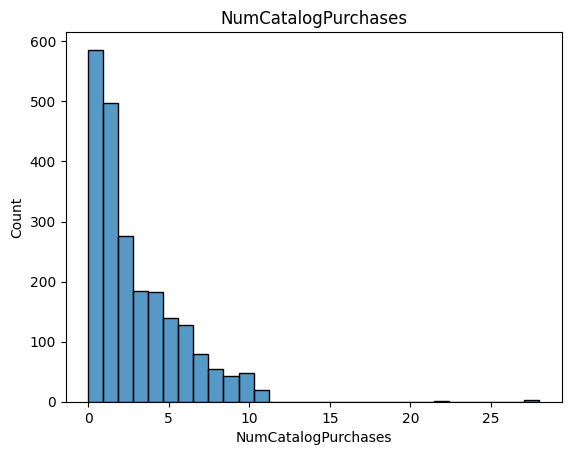

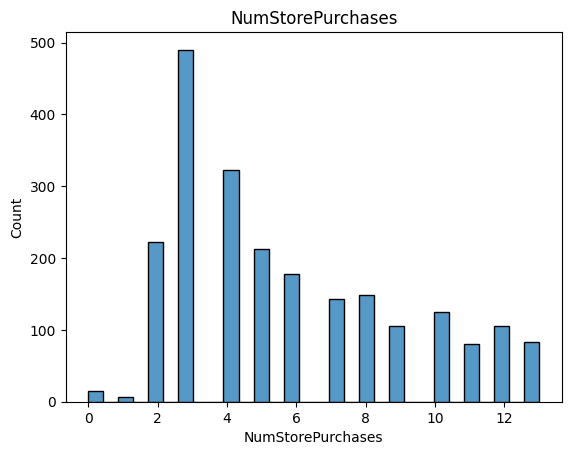

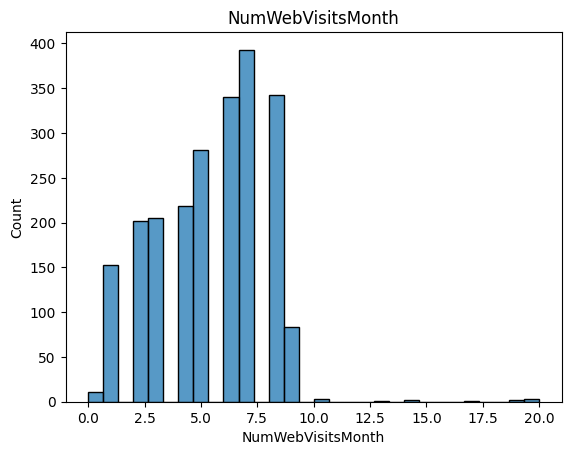

In [ ]:
plt.figure(figsize=(16, 10))

for var in int_columns:
    sns.histplot(df[var], bins=30)
    plt.title(var)
    plt.show()

Теперь давайте сравнием распределения среди групп клиентов, у которых `Response = 1` и у которых `Response = 0`

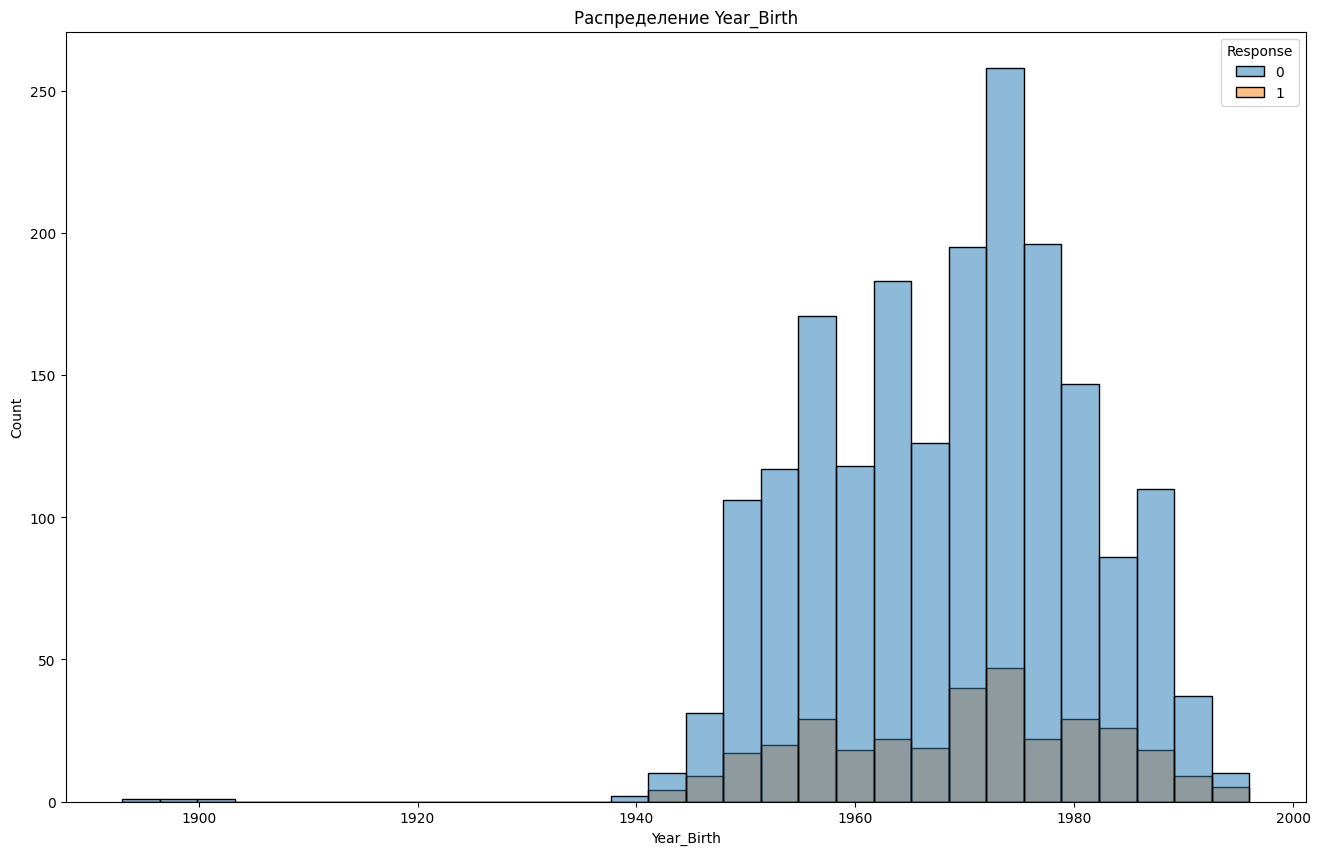

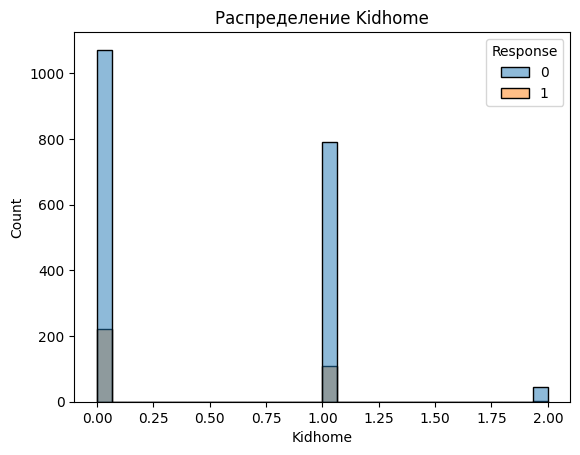

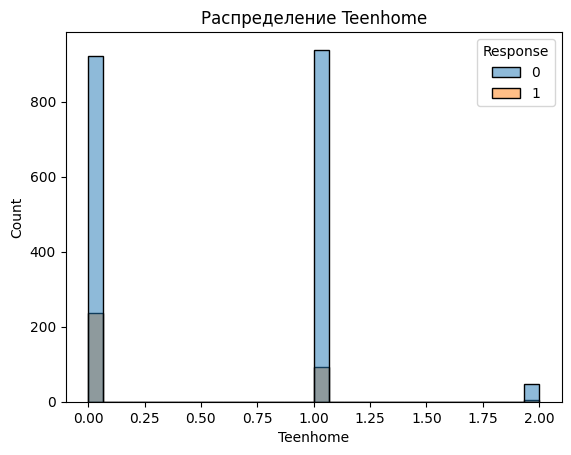

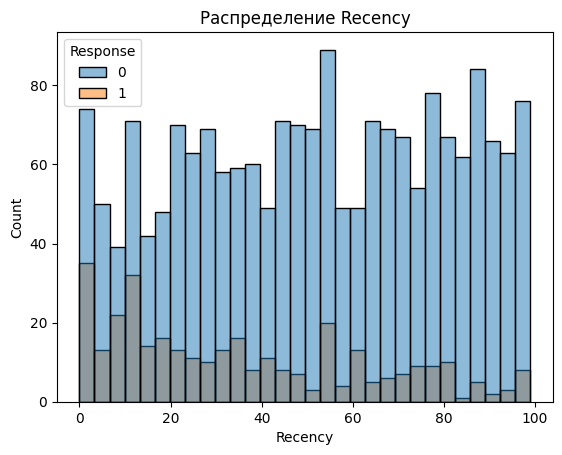

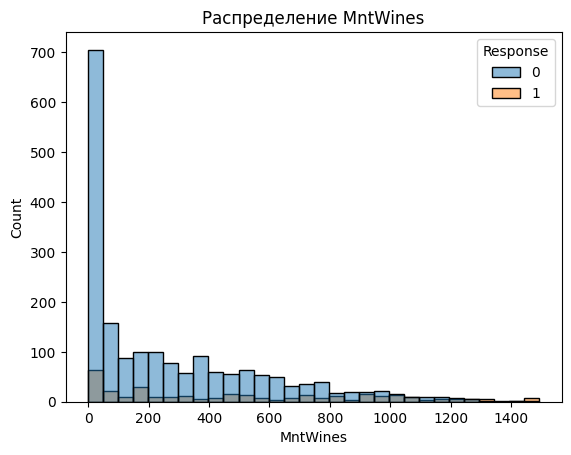

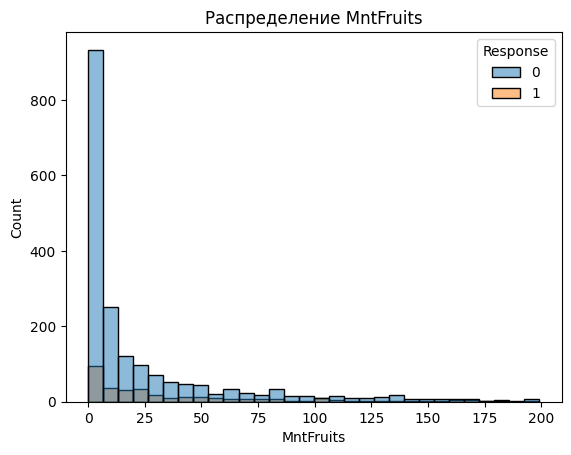

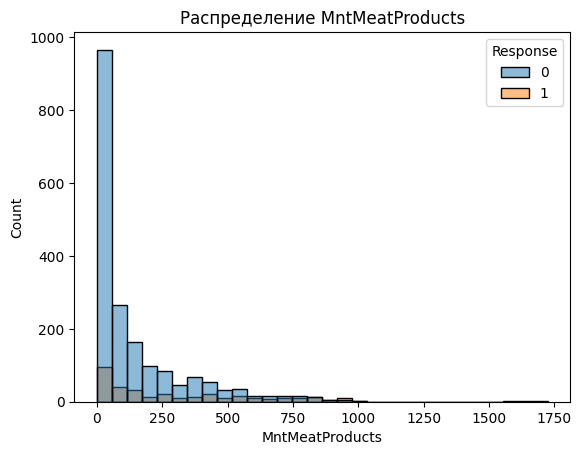

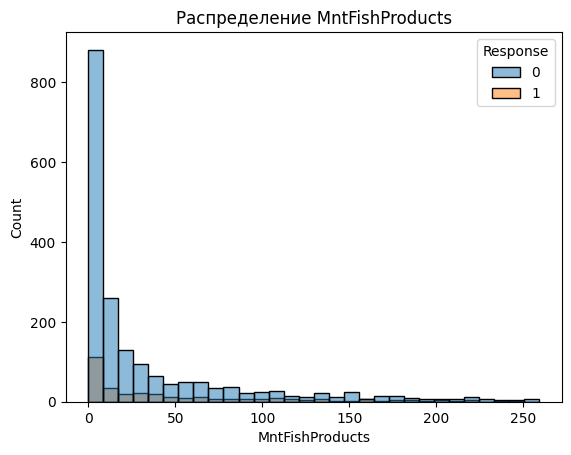

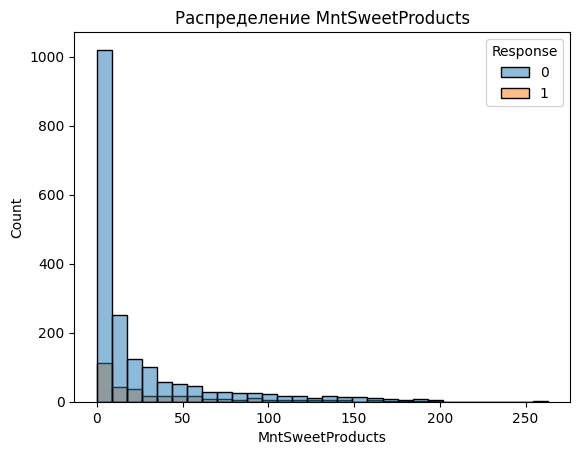

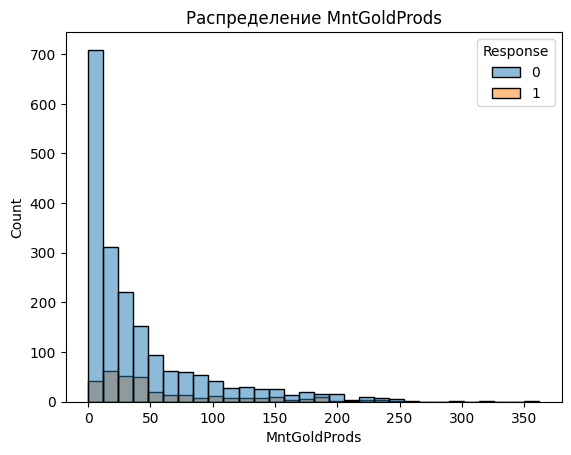

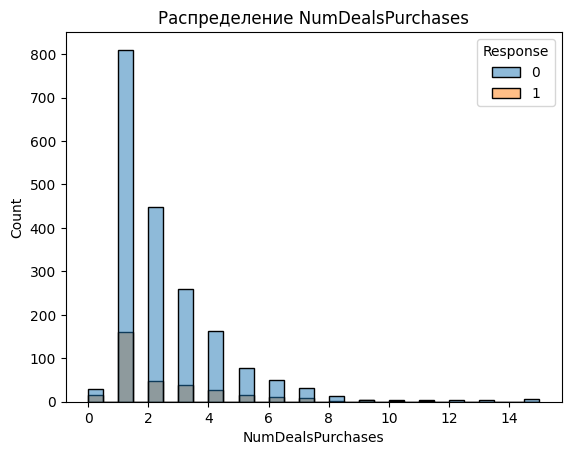

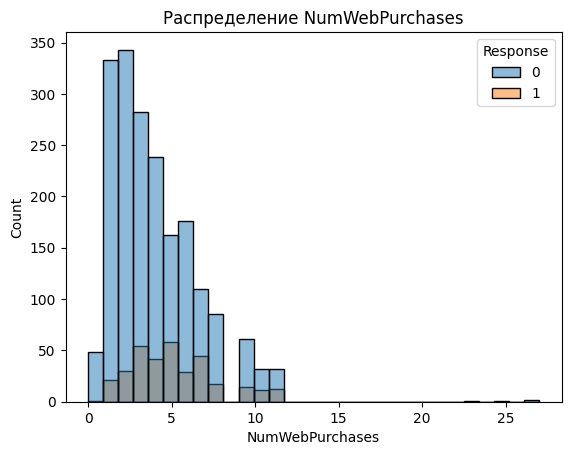

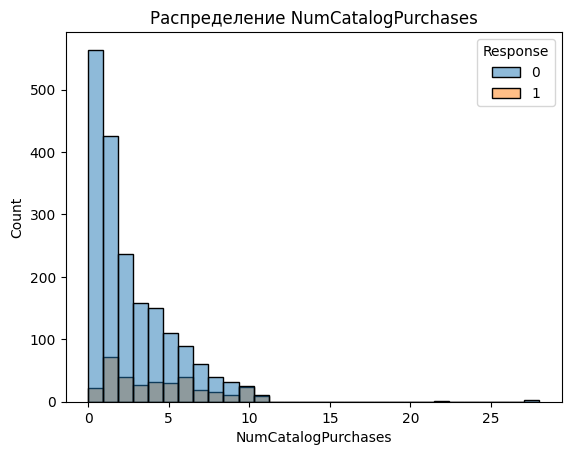

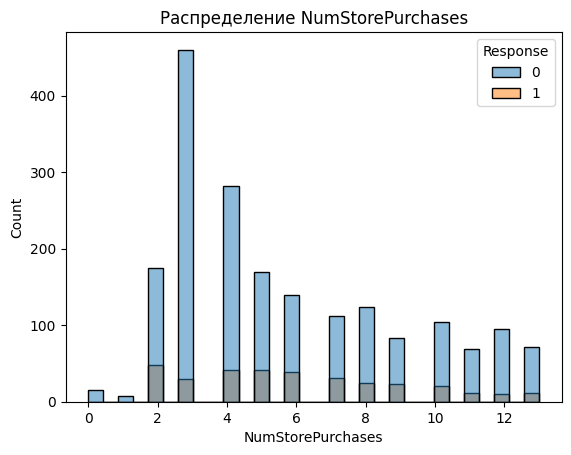

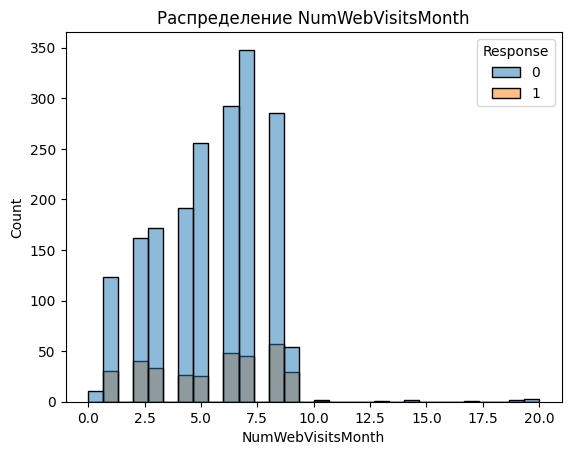

In [ ]:
plt.figure(figsize=(16, 10))

for var in int_columns:
    sns.histplot(df, x = var, hue = 'Response', bins=30)
    plt.title(f'Распределение {var}')
    plt.show()

In [ ]:
df.groupby(['Response'])[['Income', 'Teenhome', 'Kidhome']].describe()

Income                                                        \
           count          mean           std     min      25%      50%   
Response                                                                 
0         1883.0  50839.132767  25252.804747  1730.0  34421.0  50150.0   
1          333.0  60209.675676  23194.080987  7500.0  39763.0  64090.0   

                            Teenhome            ...           Kidhome  \
              75%       max    count      mean  ...  75%  max   count   
Response                                        ...                     
0         66308.0  666666.0   1906.0  0.541448  ...  1.0  2.0  1906.0   
1         80589.0  105471.0    334.0  0.305389  ...  1.0  2.0   334.0   

                                                       
              mean       std  min  25%  50%  75%  max  
Response                                               
0         0.462225  0.544975  0.0  0.0  0.0  1.0  2.0  
1         0.341317  0.487347  0.0  0.0  0.0  1.0  2.0  

[2 rows x 24 columns]

In [ ]:
df.groupby(['Response'])[['Income', 'Teenhome', 'Kidhome']].describe()

Income                                                        \
           count          mean           std     min      25%      50%   
Response                                                                 
0         1883.0  50839.132767  25252.804747  1730.0  34421.0  50150.0   
1          333.0  60209.675676  23194.080987  7500.0  39763.0  64090.0   

                            Teenhome            ...           Kidhome  \
              75%       max    count      mean  ...  75%  max   count   
Response                                        ...                     
0         66308.0  666666.0   1906.0  0.541448  ...  1.0  2.0  1906.0   
1         80589.0  105471.0    334.0  0.305389  ...  1.0  2.0   334.0   

                                                       
              mean       std  min  25%  50%  75%  max  
Response                                               
0         0.462225  0.544975  0.0  0.0  0.0  1.0  2.0  
1         0.341317  0.487347  0.0  0.0  0.0  1.0  2.0  

[2 rows x 24 columns]

In [ ]:
df.select_dtypes(['object']).columns

Index(['Education', 'Marital_Status', 'Dt_Customer'], dtype='object')

Теперь построим графики бинарных и категориальных переменных.

<Axes: xlabel='Response', ylabel='count'>

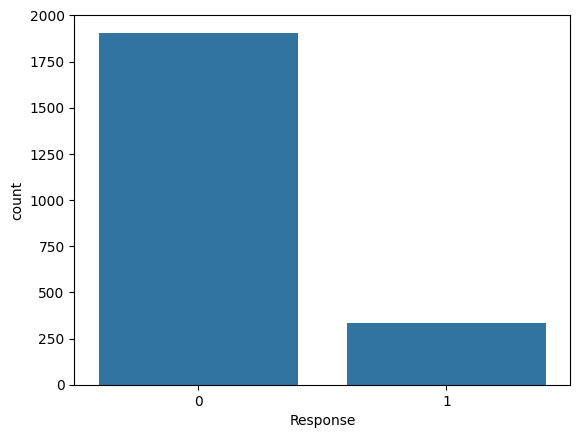

In [ ]:
sns.countplot(data=df, x = 'Response')

In [ ]:
categorical_variables = ['Education', 'Marital_Status']

In [ ]:
bool_variables = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain']

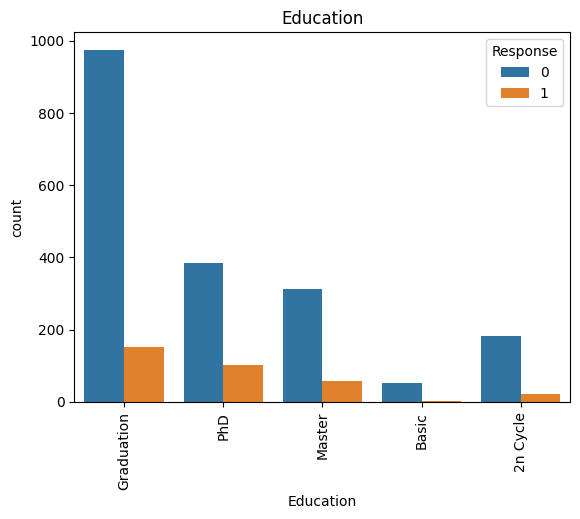

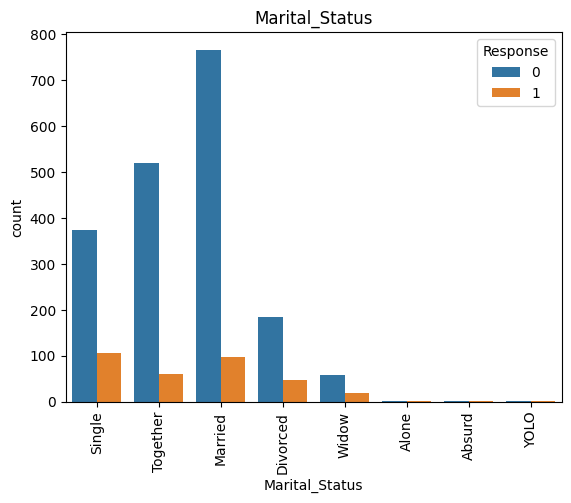

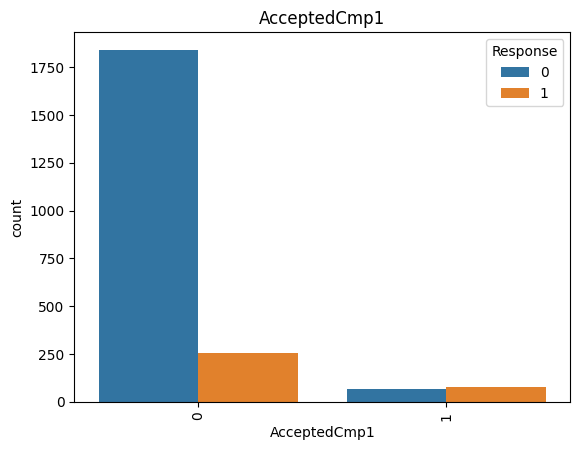

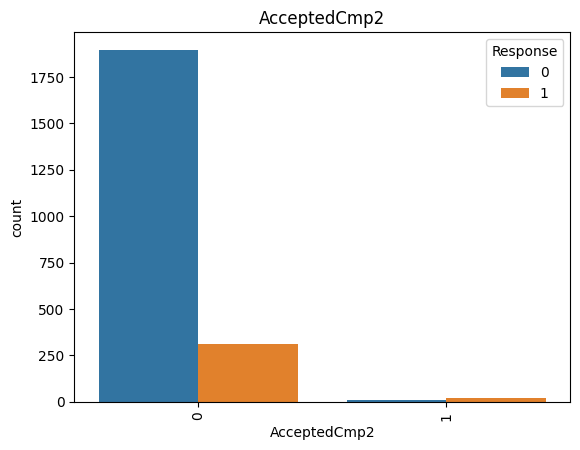

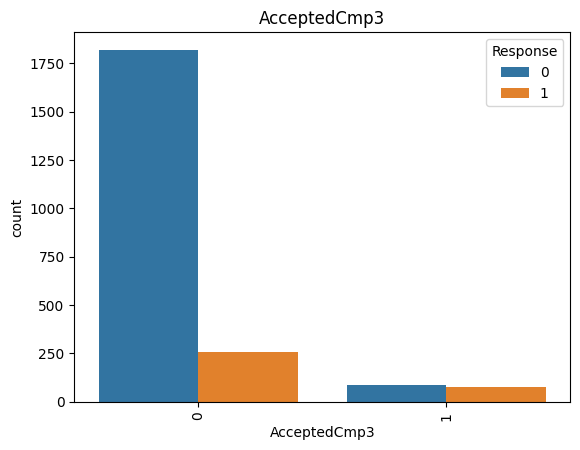

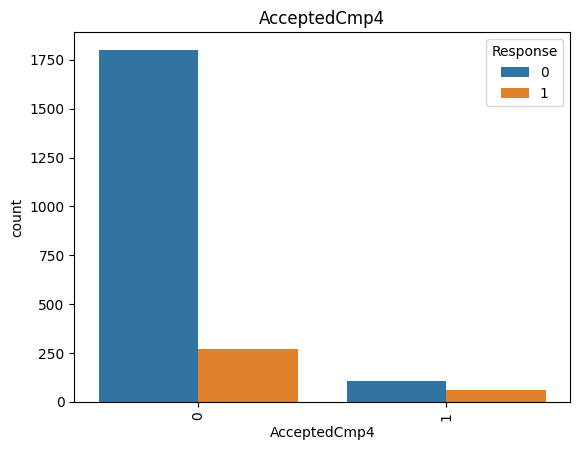

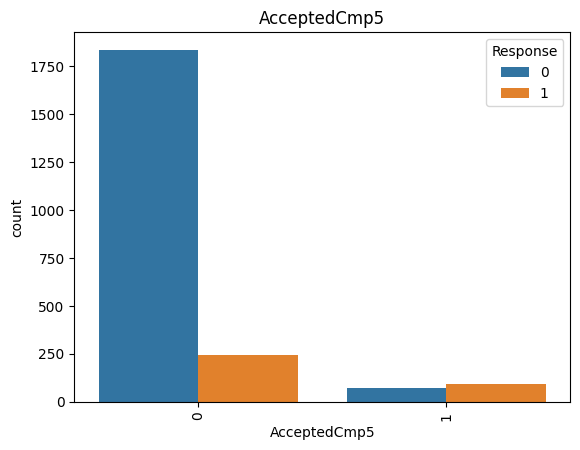

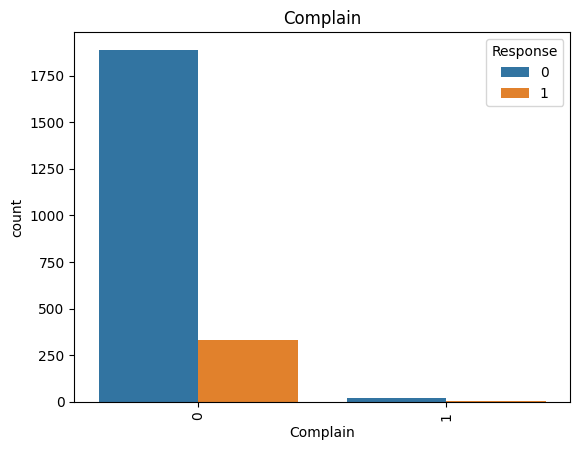

In [ ]:
for i, var in enumerate(categorical_variables + bool_variables, 1):
    sns.countplot(data=df, x = var, hue = 'Response')
    plt.title(var)
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
df.groupby(['Marital_Status'])['ID'].count()

,ID
Marital_Status,
Absurd,2
Alone,3
Divorced,232
Married,864
Single,480
Together,580
Widow,77
YOLO,2


Посмотрим на "необычные" значения переменной `Marital_Status`.

In [ ]:
df[(df['Marital_Status'] == 'Absurd') | (df['Marital_Status'] == 'YOLO')]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
2093,7734,1993,Graduation,Absurd,79244.0,0,0,2012-12-19,58,471,...,10,7,1,0,0,1,1,0,0,1
2134,4369,1957,Master,Absurd,65487.0,0,0,2014-01-10,48,240,...,5,6,2,0,0,0,0,0,0,0
2177,492,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,0
2202,11133,1973,PhD,YOLO,48432.0,0,1,2012-10-18,3,322,...,1,6,8,0,0,0,0,0,0,1


In [ ]:
df['Marital_Status']  = np.where(df['Marital_Status'].isin(['Absurd', 'YOLO', 'Alone']), 'Single', df['Marital_Status'])

In [ ]:
df.groupby(['Marital_Status'])['ID'].count()

,ID
Marital_Status,
Divorced,232
Married,864
Single,487
Together,580
Widow,77


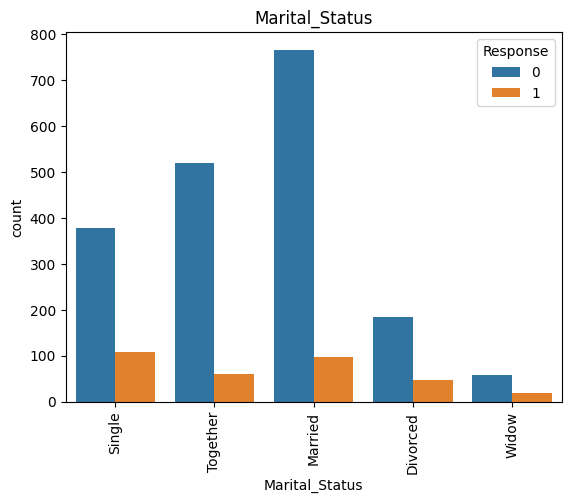

In [ ]:
sns.countplot(data=df, x = 'Marital_Status', hue = 'Response')
plt.title('Marital_Status')
plt.xticks(rotation=90)
plt.show()

Посмотрим на доли откликнувшихся в разрезе образования и семейного положения:

In [ ]:
df.groupby(['AcceptedCmp2'])[['Response']].agg(['count', 'mean'])

Response          
                count      mean
AcceptedCmp2                   
0                2210  0.142081
1                  30  0.666667

In [ ]:
df.groupby(['Marital_Status'])[['Response']].agg(['count', 'mean'])

Response          
                  count      mean
Marital_Status                   
Divorced            232  0.206897
Married             864  0.113426
Single              487  0.223819
Together            580  0.103448
Widow                77  0.246753

In [ ]:
df.groupby(['Kidhome'])[['Response']].agg(['count', 'mean'])

Response          
           count      mean
Kidhome                   
0           1293  0.171694
1            899  0.122358
2             48  0.041667

Построим boxplot-ы некоторых числовых переменных для каждого значения целевой переменной.

<Axes: xlabel='Response', ylabel='Income'>

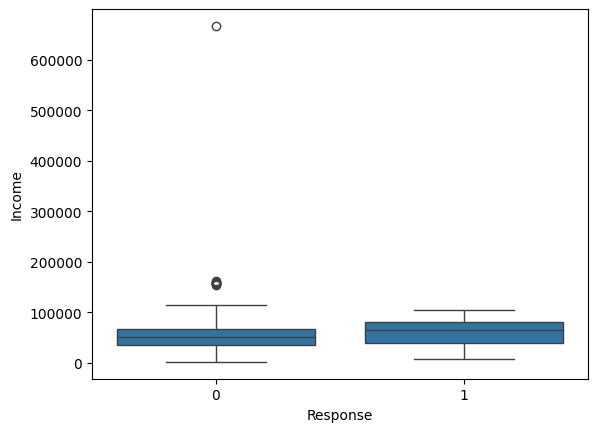

In [ ]:
sns.boxplot(data=df, y = 'Income', x = 'Response')

Некоторые модели, в том числе та, которую мы далее рассмотрим, работает только с категориальными переменными. Закодируем категориальные переменные методом OneHotEncoding.

One-Hot Encoding — это метод кодирования категориальных переменных, который преобразует каждую категорию в отдельные бинарные столбцы.

В библиотеке pandas для One-Hot Encoding используется функция pd.get_dummies(). Для каждого категориального столбца он создает новые бинарные столбцы, соответствующие уникальным значениям этого столбца. Каждый бинарный столбец содержит значения 1 или 0 в зависимости от принадлежности записи к данной категории.

In [ ]:
data = pd.get_dummies(df, columns = ['Education', 'Marital_Status'], drop_first=True)

Посмотрим, что получилось:

In [ ]:
data.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Complain,Response,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,1957,58138.0,0,0,2012-09-04,58,635,88,546,...,0,1,False,True,False,False,False,True,False,False
1,2174,1954,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,False,True,False,False,False,True,False,False
2,4141,1965,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,False,True,False,False,False,False,True,False
3,6182,1984,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,False,True,False,False,False,False,True,False
4,5324,1981,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,False,False,False,True,True,False,False,False


In [ ]:
data.columns

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow'],
      dtype='object')

Из столбца `Education` получилось 5 новых столбцов:  `Education_2n Cycle`, `Education_Basic`
       `Education_Graduation`, `Education_Master`, `Education_PhD`

In [ ]:
df[['ID', 'Education']].head(1)

,ID,Education
0,5524,Graduation


In [ ]:
data[['ID', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD']].head(1)

,ID,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,False,True,False,False


Удалим пропуски и выбросы из столбца Income

In [ ]:
data.dropna(subset=['Income'], inplace = True)

In [ ]:
data = data[(data['Income'] <= data['Income'].quantile(0.995))]

<Axes: xlabel='Response', ylabel='Income'>

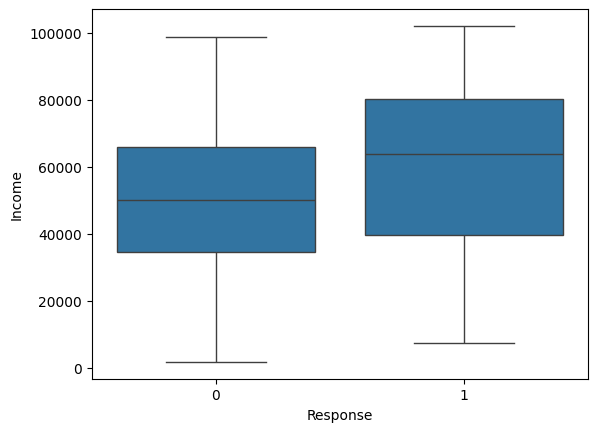

In [ ]:
sns.boxplot(data=data, y = 'Income', x = 'Response')

Из поля `Dt_Customer` получим количество дней, прошедших с первого раза, когда клиент использовал услуги кампании.
Из даты рождения получим возраст.

In [ ]:
datetime.datetime.today()

datetime.datetime(2026, 5, 16, 6, 52, 15, 971926)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2204 entries, 0 to 2239
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2204 non-null   int64  
 1   Year_Birth               2204 non-null   int64  
 2   Income                   2204 non-null   float64
 3   Kidhome                  2204 non-null   int64  
 4   Teenhome                 2204 non-null   int64  
 5   Dt_Customer              2204 non-null   object 
 6   Recency                  2204 non-null   int64  
 7   MntWines                 2204 non-null   int64  
 8   MntFruits                2204 non-null   int64  
 9   MntMeatProducts          2204 non-null   int64  
 10  MntFishProducts          2204 non-null   int64  
 11  MntSweetProducts         2204 non-null   int64  
 12  MntGoldProds             2204 non-null   int64  
 13  NumDealsPurchases        2204 non-null   int64  
 14  NumWebPurchases          2204

In [ ]:
data['days'] = (datetime.datetime(2015, 1, 1, 0, 0, 0) -  pd.to_datetime(data['Dt_Customer'])).dt.days
data = data.drop(['Dt_Customer'], axis=1)

In [ ]:
data['Year_Birth'].min()

1893

In [ ]:
data['Age'] = 2015 - data['Year_Birth']
data = data.drop(['Year_Birth'], axis=1)

In [ ]:
data.head()

,ID,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,days,Age
0,5524,58138.0,0,0,58,635,88,546,172,88,...,False,True,False,False,False,True,False,False,849,58
1,2174,46344.0,1,1,38,11,1,6,2,1,...,False,True,False,False,False,True,False,False,299,61
2,4141,71613.0,0,0,26,426,49,127,111,21,...,False,True,False,False,False,False,True,False,498,50
3,6182,26646.0,1,0,26,11,4,20,10,3,...,False,True,False,False,False,False,True,False,325,31
4,5324,58293.0,1,0,94,173,43,118,46,27,...,False,False,False,True,True,False,False,False,347,34


In [ ]:
data.drop(['ID'], axis=1, inplace=True) # удалим идентификатор клиента - для анализа он не нужен

Теперь построим таблицу корреляций между переменными.
Коэффициент корреляция Пирсона измеряется по шкале от -1 до 1. 0 - отсутствие линейной связи, значения, близкие к -1 - сильная отрицательная линейная связь, 1 - сильная положительная линейная связь.

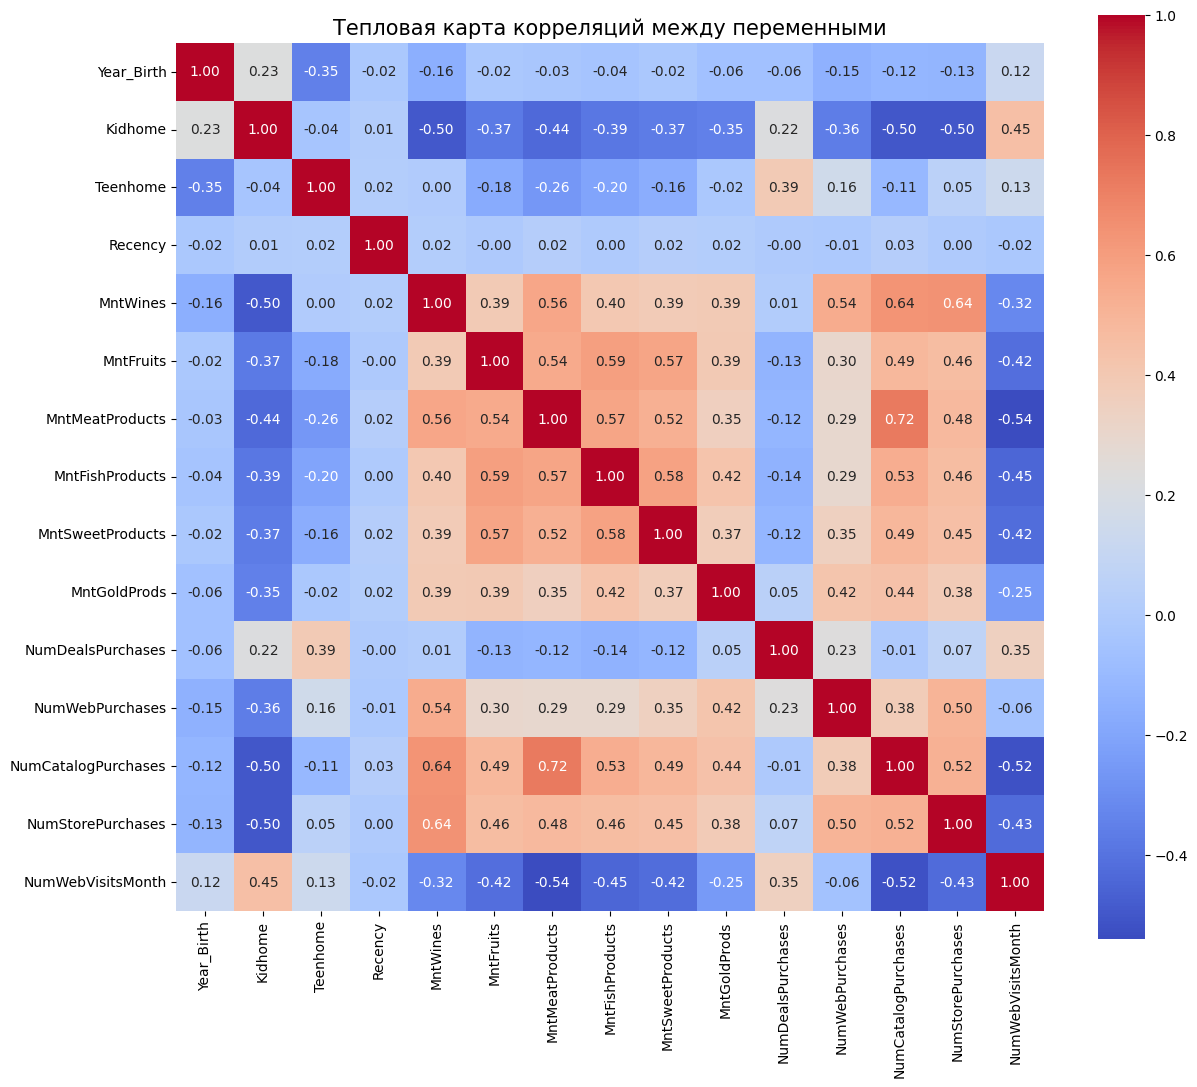

In [ ]:
correlation_matrix = df[int_columns].corr(numeric_only=True)

# Строим тепловую карту (heatmap) корреляций
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Тепловая карта корреляций между переменными', fontsize=15)
plt.yticks(rotation=0)
plt.show()

## Логистическая регрессия

Попробуем научиться предсказывать отклик клиента на кампанию с помощью логистической регрессии.

$ P(Response = 1) = \sigma(w_0+w_1*Income + ...) $,
где $ \sigma(x) = \frac{1}{1+e^{(-x)}} $

In [ ]:
X_columns = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain',
       'Education_Basic', 'Education_Graduation', 'Education_Master',
       'Education_PhD', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'days']

In [ ]:
lr =  LogisticRegression(solver='liblinear')
X = data.drop(['Response'], axis=1)
y = data['Response']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
ytrain.value_counts()

,count
Response,
0,1314
1,228


In [ ]:
Xtrain = Xtrain[X_columns]
Xtest = Xtest[X_columns]
lr.fit(Xtrain, ytrain)
pred_train = lr.predict(Xtrain)
pred_test = lr.predict(Xtest)
pred_train_prob = lr.predict_proba(Xtrain)
pred_test_prob = lr.predict_proba(Xtest)

#### Метрики качества модели

##### **Accuracy, Precision, Recall, F1**

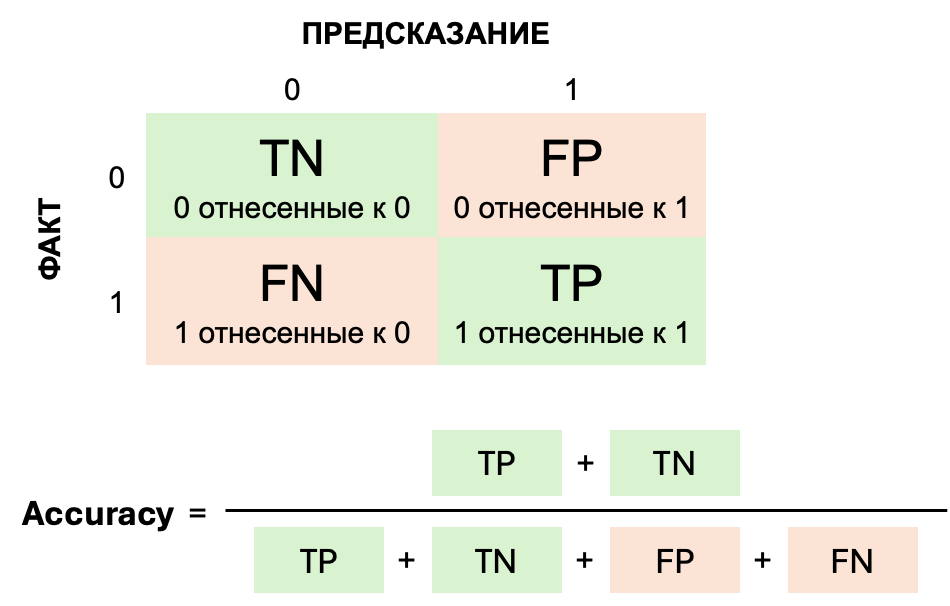

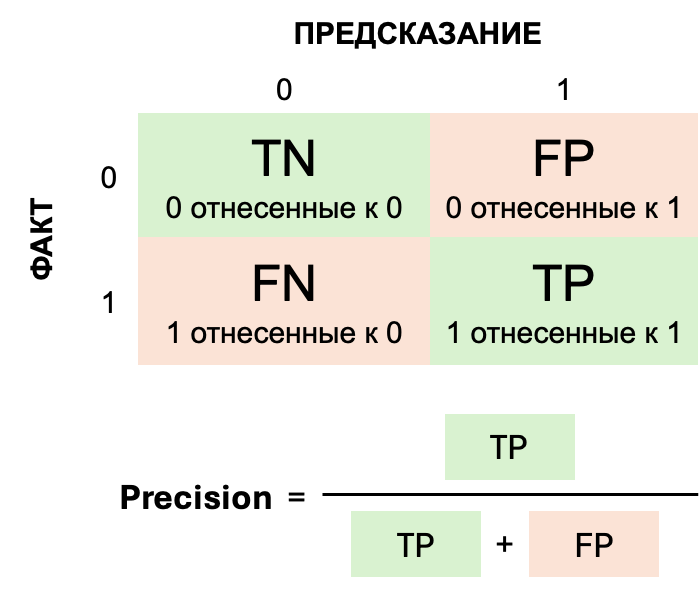

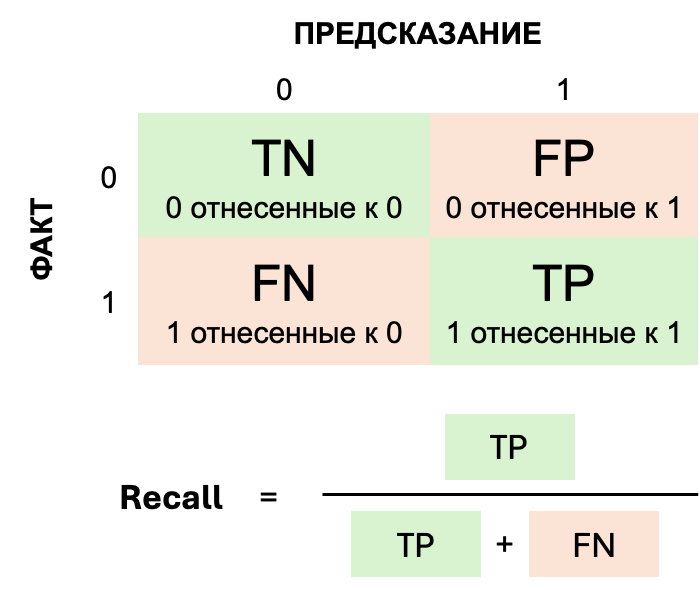

In [ ]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_prob[:, 1]), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_prob[:, 1]), 3))

Accuracy score, train: 0.866
Recall score, train: 0.246
Precision score, train: 0.615
ROC AUC, train: 0.84

Accuracy score, test: 0.863
Recall score, test: 0.304
Precision score, test: 0.608
ROC AUC, test: 0.82


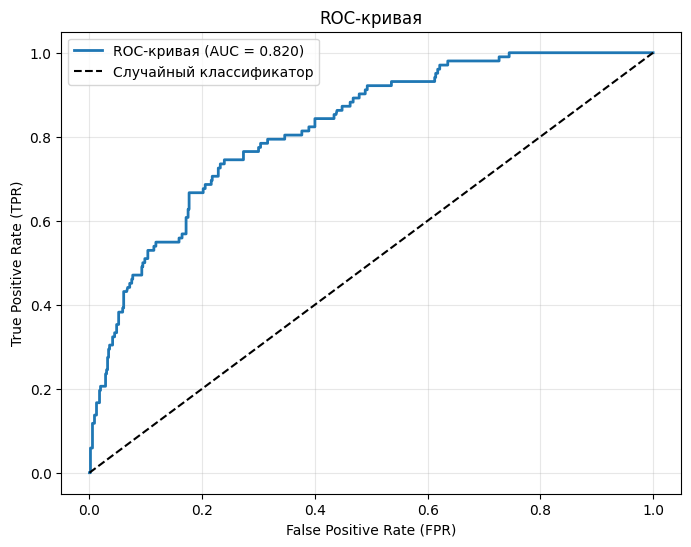

In [ ]:
fpr, tpr, thresholds = roc_curve(ytest,  pred_test_prob[:, 1])
auc = roc_auc_score(ytest, pred_test_prob[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

PR AUC (Average Precision) = 0.480


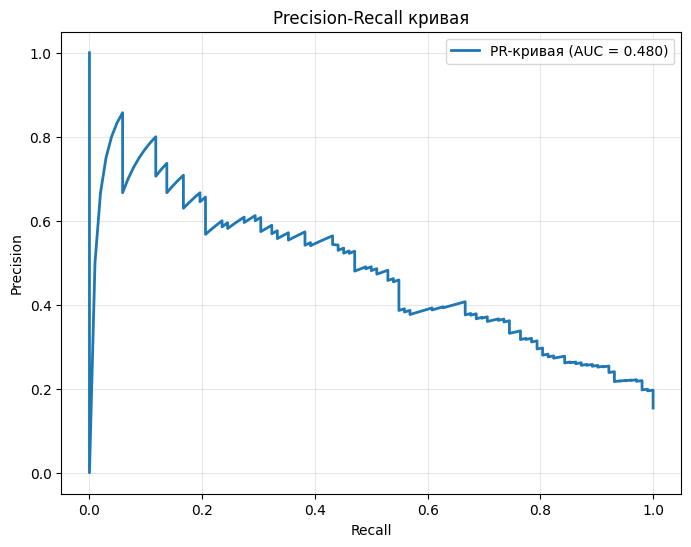

In [ ]:
precision, recall, thresholds = precision_recall_curve(ytest, pred_test_prob[:, 1])

pr_auc = average_precision_score(ytest, pred_test_prob[:, 1])
print(f"PR AUC (Average Precision) = {pr_auc:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR-кривая (AUC = {pr_auc:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Наивные предсказания:

In [ ]:
pred_train_0 = np.zeros(Xtrain.shape[0]) # никто не откликнется
pred_test_0 = np.zeros(Xtest.shape[0])
pred_train_2 = Xtrain['AcceptedCmp2'] # отклик будет как в компании 2
pred_test_2 = Xtest['AcceptedCmp2']

In [ ]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train_0), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train_0), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train_0), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test_0), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_0), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_0), 3))

Accuracy score, train: 0.852
Recall score, train: 0.0
Precision score, train: 0.0

Accuracy score, test: 0.846
Recall score, test: 0.0
Precision score, test: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train_2), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train_2), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train_2), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_2), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test_2), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test_2), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test_2), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_2), 3))

Accuracy score, train: 0.854
Recall score, train: 0.048
Precision score, train: 0.579
ROC AUC, train: 0.521

Accuracy score, test: 0.855
Recall score, test: 0.078
Precision score, test: 0.8
ROC AUC, test: 0.537


Стандартизируем данные:

In [ ]:
scaler = StandardScaler()
scaler.fit(Xtrain)
Xtrain_norm = scaler.transform(Xtrain)
Xtest_norm = scaler.transform(Xtest)
lr =  LogisticRegression(solver= 'liblinear')
lr.fit(Xtrain_norm, ytrain)
pred_train = lr.predict(Xtrain_norm)
pred_test = lr.predict(Xtest_norm)
pred_train_prob = lr.predict_proba(Xtrain_norm)
pred_test_prob = lr.predict_proba(Xtest_norm)

In [ ]:
print('Accuracy score, train:', round(accuracy_score(ytrain, pred_train), 3))
print('Recall score, train:',  round(recall_score(ytrain, pred_train), 3))
print('Precision score, train:', round(precision_score(ytrain, pred_train), 3))
print('ROC AUC, train:', round(roc_auc_score(ytrain, pred_train_prob[:, 1]), 3))

print('\nAccuracy score, test:', round(accuracy_score(ytest, pred_test), 3))
print('Recall score, test:',  round(recall_score(ytest, pred_test), 3))
print('Precision score, test:', round(precision_score(ytest, pred_test), 3))
print('ROC AUC, test:', round(roc_auc_score(ytest, pred_test_prob[:, 1]), 3))

Accuracy score, train: 0.901
Recall score, train: 0.513
Precision score, train: 0.741
ROC AUC, train: 0.921

Accuracy score, test: 0.9
Recall score, test: 0.49
Precision score, test: 0.781
ROC AUC, test: 0.896
